In [23]:
import gc
import hashlib
import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "model_lstm" / "LSTM_model_train_tune.py").exists())
if str(ROOT / "model_lstm") not in sys.path:
    sys.path.insert(0, str(ROOT / "model_lstm"))
from LSTM_databuilder_tune import (
    AssistSequenceDataset, TASK_NAMES,
    window_class_counts, training_pos_weights,
)
from LSTM_model_train_tune import AssistLSTM, AssistLoss
from LSTM_engine_tune import L1_SETTINGS, run_epoch, fit_model

In [17]:
def release_notebook_data(*names):
    for name in names:
        globals().pop(name, None)
    gc.collect()


def make_datasets(paths):
    if not paths:
        raise ValueError("No normalized NPZ files found")
    result = []
    for path in paths:
        path = Path(path)
        result.append(AssistSequenceDataset(
            npz_path=path, window_size=window_size,
            stride=stride, predict_offset=predict_offset, mode=mode,
            feature_keys=x_keys, cache_dir=dataset_cache_dir,
            expected_normalization_id=fold_manifest["normalization_id"],
        ))
    if not sum(map(len, result)):
        raise ValueError("No complete windows found")
    print(f"Loaded {len(result)} files, {sum(map(len, result)):,} windows")
    return result

In [18]:
test_notes = "Claude L1 LSTM protocol: 251 features, four heads, peak BCE, original validation/test, fold-specific normalization and LOSO split."

In [19]:
#device 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Claude L1 (LSTM) protocol
251 inputs; hidden 128; dropout 0.3; continuous 120-frame windows / hop 10.
AdamW, lr=1e-3, weight_decay=1e-4; batch 256; 12 epochs; cosine schedule; gradient norm <=1.
This notebook runs one selected LOSO fold. Use LSTM_loso_tune.py for all 15 folds.
The baseline files and previous experiments remain separate. Document settings are aligned;
the unavailable Claude source/data snapshot prevents claiming bit-for-bit reproduction.

Task labels are seven independent peak values. Idle frames remain in task BCE.
Progress loss uses active plateau lanes, and task metrics exclude **true** idle windows.
The old scalar task_id is used only to plot the training window distribution.

## Training configuration

In [20]:
# Claude L1, not the GRU S3 variant.
test_uid = 15
fold_index = test_uid - 1
epochs = L1_SETTINGS["epochs"]
batch_size = L1_SETTINGS["batch_size"]
lr = L1_SETTINGS["learning_rate"]
window_size = L1_SETTINGS["window_size"]
stride = L1_SETTINGS["stride"]  # Window hop; samples inside each window are consecutive.
predict_offset = 0
num_workers = 0
mode = "seq2one"
dataset_cache_dir = ROOT / "model_lstm" / ".dataset_cache" / "claude_l1" / f"fold_{test_uid:02d}"
hidden_layer = L1_SETTINGS["hidden_dim"]
dropout = L1_SETTINGS["dropout"]
num_layers = 1
weight_decay = L1_SETTINGS["weight_decay"]
train_shuffle = True
shuffle_seed = fold_index
pos_weight_cap = 2.0
lambda_step, lambda_progress, lambda_mistake, lambda_idle = 1.0, 0.3, 0.3, 0.2

## load training data

In [21]:
data_root = Path("G:/.shortcut-targets-by-id/1nZZWQUKOdxeC-oo-NKucbuUj38ir4mZC/ITECH_Thesis/Videos/dataset/skeleton_3d/ceiling_panel_installation_04")
fold_dir = data_root / "claude_l1" / f"fold_{test_uid:02d}"
manifest_path = fold_dir / "dataset_manifest.json"
if not manifest_path.exists():
    raise FileNotFoundError("Export this fold with build_norm_dataset_tune.py first (same test_uid).")
fold_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
if fold_manifest["test_uid"] != test_uid or fold_manifest["profile"] != "claude_l1_v1":
    raise ValueError("Wrong fold or preprocessing profile")
npz_paths = [fold_dir / name for name in fold_manifest["files"]["train"]]
print("Training files:", len(npz_paths), "Subjects:", fold_manifest["subjects"])

Training files: 150 Subjects: {'train': [2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14], 'val': [1, 7], 'test': [15]}


## Record the normalization source used for this export

In [9]:
norm_stats_path = fold_dir / "norm_stats.npz"
norm_stats_sha256 = hashlib.sha256(norm_stats_path.read_bytes()).hexdigest()
if norm_stats_sha256 != fold_manifest["normalization_sha256"]:
    raise ValueError("Fold normalization statistics changed; do not mix exports")

## Validation files

In [10]:
npz_val_paths = [fold_dir / name for name in fold_manifest["files"]["val"]]

Run `python -B data_proc_2d/app/build_norm_dataset_tune.py` from the repository root first.
Set the raw data root and test_uid in its main block. It selects all recordings by participant;
training includes originals plus one `_aug-01` mirror, while val/test contain originals only.
Features are transformed before train-only statistics: azimuth sin/cos; ratios clipped [0,4].
Statistics sample every seventh original frame, excluding rows with non-finite features,
and accumulate in float64 (an explicit choice where Claude's document is unspecified).
Exports and statistics are isolated in `claude_l1/fold_XX/`; each NPZ carries the normalization ID.
Invalid frames keep their timeline positions; every window spanning one is rejected.
Progress is already scaled to [0,1]. No source PT, old norm directory or old statistics file is changed.

In [11]:
print("Validation files:", len(npz_val_paths))

Validation files: 12


In [12]:
FEATURE_KEYS = [
    'joint_speed', 
    'joint_acceleration', 
    'joint_velocity_x', 
    'joint_velocity_y', 
    'joint_velocity_z', 
    'joint_acceleration_x', 
    'joint_acceleration_y', 
    'joint_acceleration_z', 
    'position_x_relative_to_pelvis', 
    'position_y_relative_to_pelvis', 
    'position_z_relative_to_pelvis', 
    'polar_azimuth', 
    'polar_elevation', 
    'joint_angles', 
    'ratios', 
    'distance_from_center'
]

All 16 panels in Claude order. Azimuth has 32 sin/cos columns; total input dimension is 251.

# Select the complete, already transformed feature set.

In [13]:
x_keys = FEATURE_KEYS.copy()
if x_keys != fold_manifest["feature_keys"]:
    raise ValueError("Feature order differs from the fold export")

## training dataset

In [14]:
release_notebook_data("loader", "train_eval_loader", "full_dataset", "datasets", "x_sample", "y_sample")
datasets = make_datasets(npz_paths)
full_dataset = ConcatDataset(datasets)
train_class_counts = window_class_counts(datasets)
loader = DataLoader(full_dataset, batch_size=batch_size,
                    shuffle=train_shuffle, num_workers=num_workers,
                    generator=torch.Generator().manual_seed(shuffle_seed),
                    pin_memory=(device.type == "cuda"), drop_last=False)
train_eval_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)
print("Training uses shuffle=True: every window appears once per epoch.")
print("Training class proportions:", train_class_counts / train_class_counts.sum())

Loaded 144 files, 171,122 windows
Training uses shuffle=True: every window appears once per epoch.
Training class proportions: [0.032807   0.04018186 0.05510688 0.0981522  0.39197765 0.08208179
 0.06525169 0.23444093]


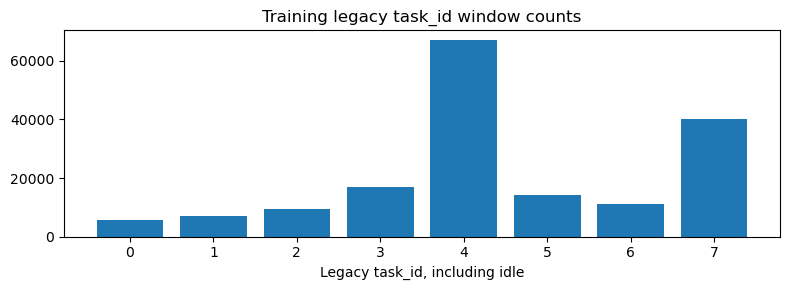

In [15]:
plt.figure(figsize=(8, 3))
plt.bar(range(8), train_class_counts)
plt.title("Training legacy task_id window counts")
plt.xlabel("Legacy task_id, including idle")
plt.tight_layout()
plt.show()

## val dataset

In [ ]:
release_notebook_data("val_loader", "fulldataset_val", "val_datasets")
val_datasets = make_datasets(npz_val_paths)
fulldataset_val = ConcatDataset(val_datasets)
val_loader = DataLoader(fulldataset_val, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)
if not any(np.any(d.plateau[d.target_slice, 7] < 0.5) for d in val_datasets):
    raise ValueError("Validation needs non-idle windows for macro-F1 model selection")

In [ ]:
val_class_counts = window_class_counts(val_datasets)
plt.figure(figsize=(8, 3))
plt.bar(range(8), val_class_counts)
plt.title("Validation legacy task_id distribution")
plt.tight_layout()
plt.show()

### model

In [ ]:
x_sample, y_sample = full_dataset[0]
input_dim = x_sample.shape[-1]
num_steps = 7
if input_dim != 251:
    raise ValueError("Claude L1 requires 251 transformed input dimensions")
torch.manual_seed(fold_index)
print("Input dimensions:", input_dim, "Window:", tuple(x_sample.shape))
print("Targets:", {key: tuple(value.shape) for key, value in y_sample.items()})
model = AssistLSTM(input_dim=input_dim, hidden_dim=hidden_layer, num_steps=num_steps,
                   dropout=dropout, num_layers=num_layers).to(device)

In [ ]:
print("Task peak:", y_sample["step"])
print("Task plateau:", y_sample["plateau"])
print("Progress (0..1):", y_sample["progress"])
print("Idle:", y_sample["idle"], "Mistake:", y_sample["mistake"])

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
pos_stats = training_pos_weights(datasets, cap=pos_weight_cap)
criterion = AssistLoss(
    task_pos_weight=pos_stats["task_pos_weight"], mistake_pos_weight=pos_stats["mistake_pos_weight"],
    lambda_step=lambda_step, lambda_progress=lambda_progress,
    lambda_mistake=lambda_mistake, lambda_idle=lambda_idle,
).to(device)
print("BCE weights from valid training window endpoints:", pos_stats)

In [ ]:
# run_epoch and fit_model are shared with the 15-fold runner.
# Training clips gradient norm at 1; fit_model steps cosine LR once per epoch.

## Log and train (run this cell to start the full experiment)

In [ ]:
import csv
from datetime import datetime

# Record the exact fold file order and normalization provenance.
def file_manifest(items):
    return [{"normalized": str(d.npz_path), "windows": len(d)} for d in items]

train_uids = {int(re.search(r"uid-(\d+)", d.npz_path.name)[1]) for d in datasets}
val_uids = {int(re.search(r"uid-(\d+)", d.npz_path.name)[1]) for d in val_datasets}
if train_uids & val_uids:
    raise ValueError("Training and validation subjects overlap")

run_dir = ROOT / "model_lstm" / "runs_3d_tune" / datetime.now().strftime("exp_%Y-%m-%d_%H-%M-%S_%f")
run_dir.mkdir(parents=True, exist_ok=False)
config = {
    "stage": "claude_l1", "test_notes": test_notes, "model": "LSTM",
    "feature_keys": x_keys, "input_dim": input_dim, "hidden_dim": hidden_layer,
    "num_steps": 7, "num_layers": num_layers, "dropout": dropout,
    "heads": {"step": 7, "progress": 7, "mistake": 1, "idle": 1},
    "window_size": window_size, "stride": stride, "stride_meaning": "window_hop",
    "predict_offset": predict_offset, "mode": mode, "sample_interval": 1,
    "test_uid": test_uid, "fold_index": fold_index, "seed": fold_index,
    "optimizer": "AdamW", "epochs": epochs, "batch_size": batch_size,
    "learning_rate": lr, "weight_decay": weight_decay, "scheduler": "CosineAnnealingLR", "gradient_clip": 1.0,
    "loss_weights": criterion.weights, "pos_weight_cap": pos_weight_cap, "pos_weight_stats": pos_stats,
    "task_target": "task_id_vector[:7]", "idle_target": "task_id_plateau_vector[7] >= 0.5",
    "progress_target": "task_progress_vector[:7] (NPZ already scaled to 0..1)", "progress_mask": "plateau[:7] >= 0.5",
    "task_metric_truth": "argmax(plateau[:7] + 0.001 * peak[:7])",
    "task_metric_filter": "true_idle == 0", "macro_f1_labels": list(range(7)),
    "progress_metric": "MAE over active lanes of true non-idle windows, multiplied by 100",
    "training_sampler": type(loader.sampler).__name__, "shuffle_seed": shuffle_seed,
    "sampler_replacement": False, "sampler_num_samples": len(full_dataset),
    "training_shuffle": train_shuffle, "train_metrics_distribution": "original_windows",
    "legacy_step_counts": train_class_counts.tolist(), "num_workers": num_workers,
    "dataset_cache_dir": str(dataset_cache_dir), "data_root": str(data_root),
    "normalization_source": str(norm_stats_path),
    "normalization_id": fold_manifest["normalization_id"], "feature_profile": fold_manifest["profile"], "normalization_sha256": norm_stats_sha256,
    "train_uids": sorted(train_uids), "val_uids": sorted(val_uids),
    "train_files": file_manifest(datasets), "val_files": file_manifest(val_datasets),
}
(run_dir / "dataset_manifest.json").write_text(json.dumps(fold_manifest, indent=2), encoding="utf-8")
fit_model(model, loader, val_loader, criterion, device, optimizer, run_dir, config)
print("Saved run:", run_dir)

---

# Evaluate model performance with test dataset

### load the best model

In [33]:
run_dir = Path("C:\\Users\\loy49\\Desktop\\REPO\\LSTM_HRC\\model_lstm\\runs_3d_tune\\L1_LOSO_2026-09-29_11-19-36_618304\\fold_15")

In [34]:
# Keep the run produced by the training cell above.
# To evaluate an older experiment, explicitly set run_dir here.
print("Evaluating run:", run_dir)


Evaluating run: C:\Users\loy49\Desktop\REPO\LSTM_HRC\model_lstm\runs_3d_tune\L1_LOSO_2026-09-29_11-19-36_618304\fold_15


In [35]:
best_model_path_dir = run_dir
best_model_path = best_model_path_dir / "best_model.pth"

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model_path_dir = run_dir
pred_df = pd.read_csv(run_dir / "test_predictions.csv")
metrics_df = pd.read_csv(run_dir / "metrics.csv")
results = json.loads(
    (run_dir / "test_results.json").read_text(encoding="utf-8")
)

## plot loss curves (train VS val)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_loss"], label="Train Loss")
ax.plot(metrics_df["val_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)



## plot loss curves (step train VS step val)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_step_loss"], label="Train Loss")
ax.plot(metrics_df["val_step_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Step Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Step_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (Mistake train VS step val)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_mistake_loss"], label="Train Loss")
ax.plot(metrics_df["val_mistake_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Mistake Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Mistake_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

## plot loss curves (progress train VS step val)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_df = pd.read_csv(best_model_path_dir / "metrics.csv")
ax.plot(metrics_df["train_progress_loss"], label="Train Loss")
ax.plot(metrics_df["val_progress_loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Progress Training / Validation Loss")
ax.legend()

fig.tight_layout()
fig.savefig(best_model_path_dir / "Progress_training_loss_plot.png", dpi=200, bbox_inches="tight")

plt.show()
plt.close(fig)

In [ ]:
best_model_config = json.loads((best_model_path_dir / "config.json").read_text(encoding="utf-8"))
criterion_eval = AssistLoss(
    task_pos_weight=best_model_config["pos_weight_stats"]["task_pos_weight"],
    mistake_pos_weight=best_model_config["pos_weight_stats"]["mistake_pos_weight"],
    **{f"lambda_{key}": value for key, value in best_model_config["loss_weights"].items()},
).to(device)
# Avoid silently evaluating a checkpoint with a different dataset configuration.
for key, value in {"normalization_id": fold_manifest["normalization_id"],
                   "normalization_sha256": norm_stats_sha256, "test_uid": test_uid,
                   "feature_keys": x_keys, "window_size": window_size, "stride": stride,
                   "predict_offset": predict_offset, "mode": mode}.items():
    if best_model_config[key] != value:
        raise ValueError(f"Set {key} to the selected run's config before building evaluation data")

In [ ]:
model_eval = AssistLSTM(**{key: best_model_config[key] for key in
                         ("input_dim", "hidden_dim", "num_steps", "dropout", "num_layers")}).to(device)
model_eval.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
model_eval.eval()

### Train confusion matrix (best validation checkpoint)

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

train_eval_metrics, train_pred_df = run_epoch(
    model_eval, train_eval_loader, criterion_eval, device, collect_predictions=True,
)
train_pred_df.to_csv(best_model_path_dir / "train_predictions.csv", index=False)
(best_model_path_dir / "train_results.json").write_text(json.dumps(train_eval_metrics, indent=2), encoding="utf-8")
train_active = train_pred_df[train_pred_df.true_idle == 0]
for normalize, suffix, values_format in [(None, "", "d"), ("true", "_norm", ".2f")]:
    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay.from_predictions(
        train_active.true_step, train_active.pred_step, labels=range(7),
        display_labels=TASK_NAMES, normalize=normalize, values_format=values_format,
        xticks_rotation=45, ax=ax,
    )
    ax.set_title("Train tasks, true non-idle windows (sequential evaluation)")
    fig.tight_layout()
    fig.savefig(best_model_path_dir / f"train_step_confusion_matrix{suffix}.png", dpi=200)
    plt.show()
    plt.close(fig)

NameError: name 'model_eval' is not defined

## Test files: held-out participant, originals only

In [ ]:
release_notebook_data("loader", "train_eval_loader", "full_dataset", "datasets",
                      "val_loader", "fulldataset_val", "val_datasets", "x_sample", "y_sample",
                      "train_pred_df", "train_active")
npz_test_paths = [fold_dir / name for name in fold_manifest["files"]["test"]]

In [ ]:
print("Test files:", len(npz_test_paths))

## test dataset

In [ ]:
release_notebook_data("test_loader", "fulldataset_test", "test_datasets", "pred_df")
test_datasets = make_datasets(npz_test_paths)
test_uids = {int(re.search(r"uid-(\d+)", d.npz_path.name)[1]) for d in test_datasets}
if test_uids & (set(best_model_config["train_uids"]) | set(best_model_config["val_uids"])):
    raise ValueError("Test subjects overlap with training/validation")
fulldataset_test = ConcatDataset(test_datasets)
test_loader = DataLoader(fulldataset_test, batch_size=best_model_config["batch_size"], shuffle=False,
                         num_workers=num_workers, pin_memory=(device.type == "cuda"), drop_last=False)

In [ ]:
print("Test legacy task_id counts:", window_class_counts(test_datasets))

In [ ]:
results, pred_df = run_epoch(model_eval, test_loader, criterion_eval, device, collect_predictions=True)
# Sequential evaluation order makes these source locations exact.
pred_df["file"] = np.concatenate([np.repeat(d.npz_path.name, len(d)) for d in test_datasets])
pred_df["target_frame"] = np.concatenate([
    np.asarray(d.indices) + d.window_size - 1 + d.predict_offset for d in test_datasets
])
print(results)

In [ ]:
pred_df.to_csv(best_model_path_dir / "test_predictions.csv", index=False)
(best_model_path_dir / "test_results.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
(best_model_path_dir / "test_files.json").write_text(json.dumps(file_manifest(test_datasets), indent=2), encoding="utf-8")

### Step prediction

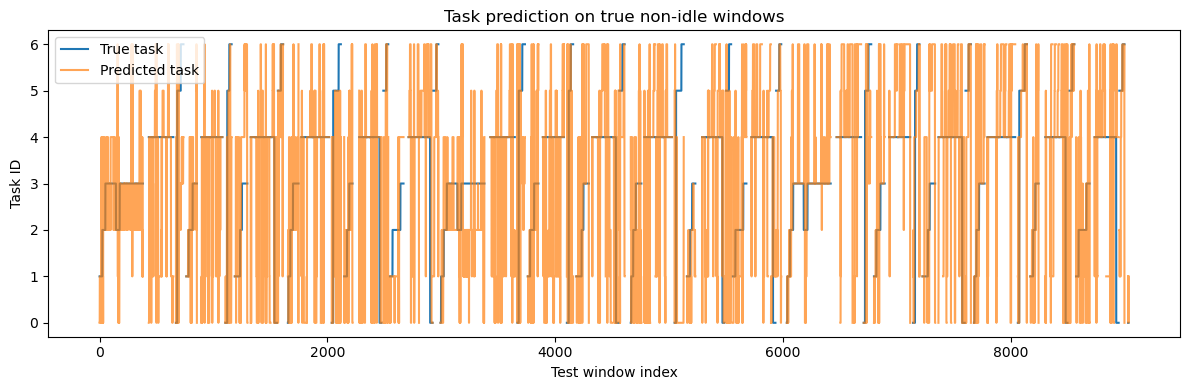

In [29]:
fig, ax = plt.subplots(figsize=(12, 4))
non_idle = pred_df.true_idle == 0
ax.plot(pred_df.sample_index, pred_df.true_step.where(non_idle), label="True task")
ax.plot(pred_df.sample_index, pred_df.pred_step.where(non_idle), label="Predicted task", alpha=0.7)
ax.set(xlabel="Test window index", ylabel="Task ID", title="Task prediction on true non-idle windows")
ax.legend()
fig.tight_layout()
fig.savefig(best_model_path_dir / "step_prediction_plot.png", dpi=200)
plt.show()
plt.close(fig)

### Progress prediction & error

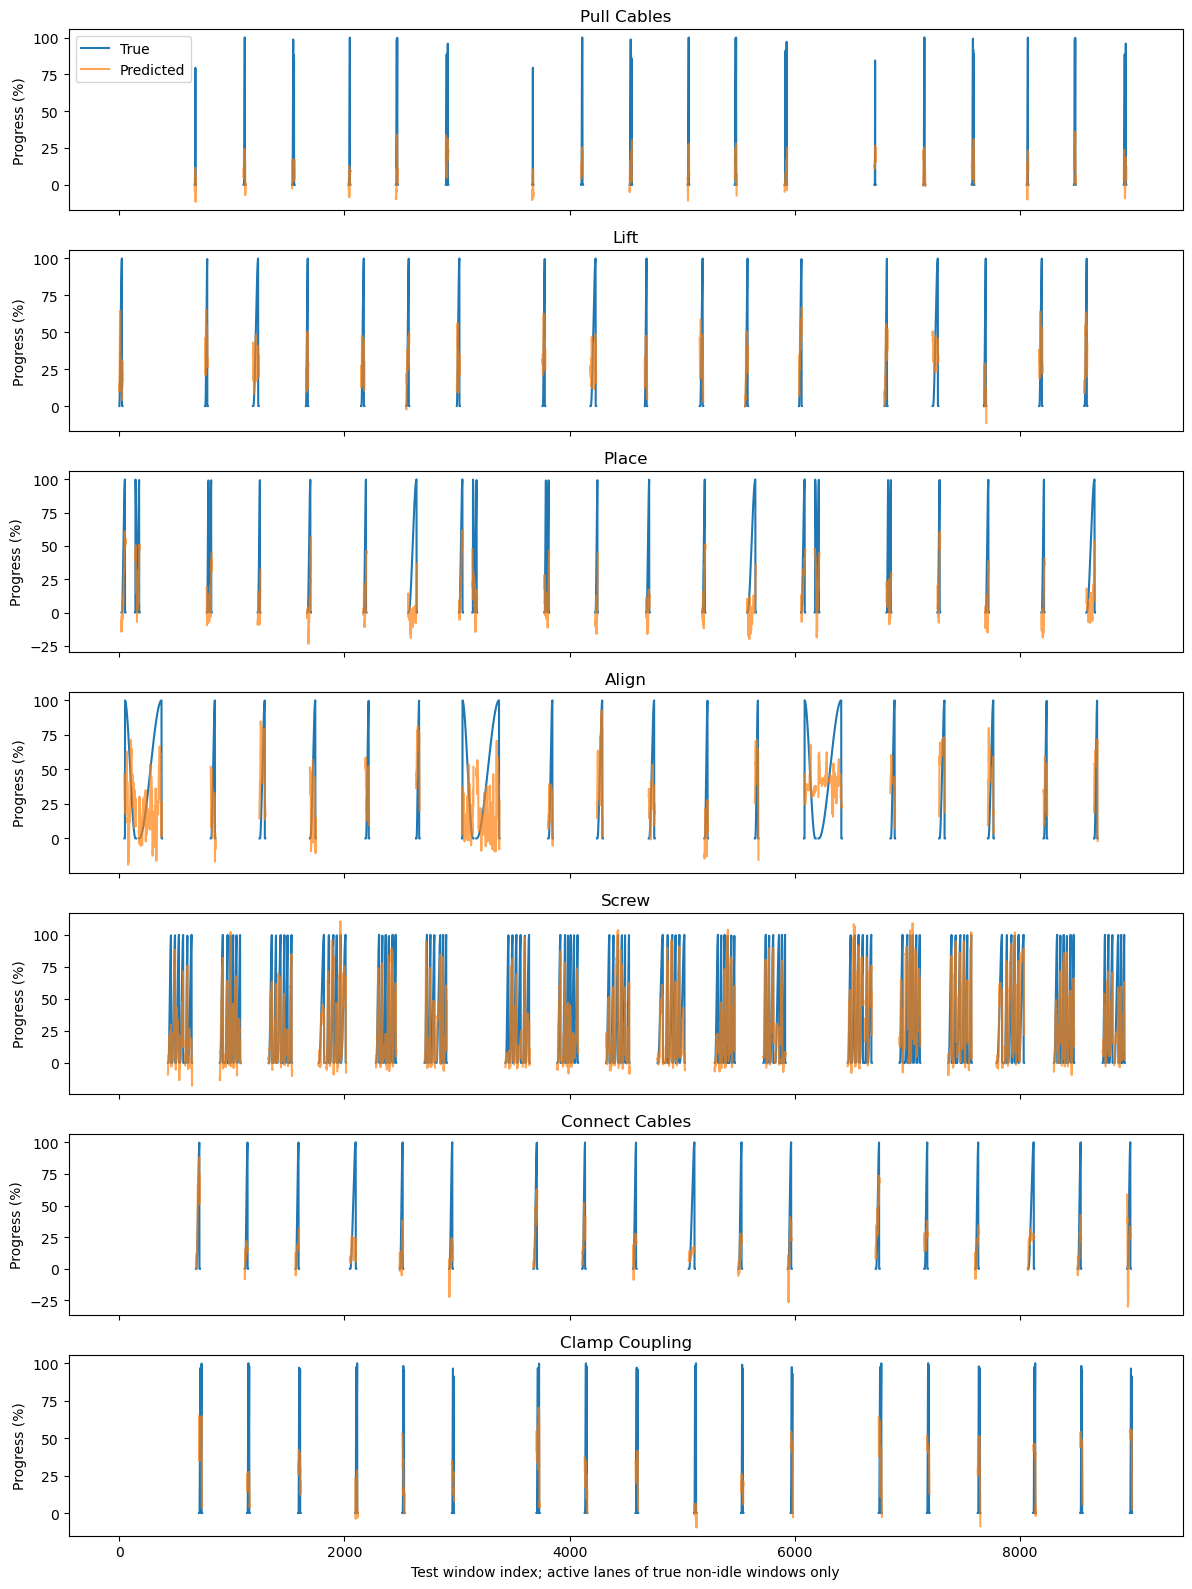

In [30]:
fig, axes = plt.subplots(7, 1, figsize=(12, 16), sharex=True)
for lane, ax in enumerate(axes):
    mask = pred_df[f"progress_active_{lane}"]
    ax.plot(pred_df.sample_index, 100 * pred_df[f"true_progress_{lane}"].where(mask), label="True")
    ax.plot(pred_df.sample_index, 100 * pred_df[f"pred_progress_{lane}"].where(mask), label="Predicted", alpha=0.7)
    ax.set(ylabel="Progress (%)", title=TASK_NAMES[lane])
axes[0].legend()
axes[-1].set_xlabel("Test window index; active lanes of true non-idle windows only")
fig.tight_layout()
fig.savefig(best_model_path_dir / "progress_prediction_plot.png", dpi=200)
plt.show()
plt.close(fig)

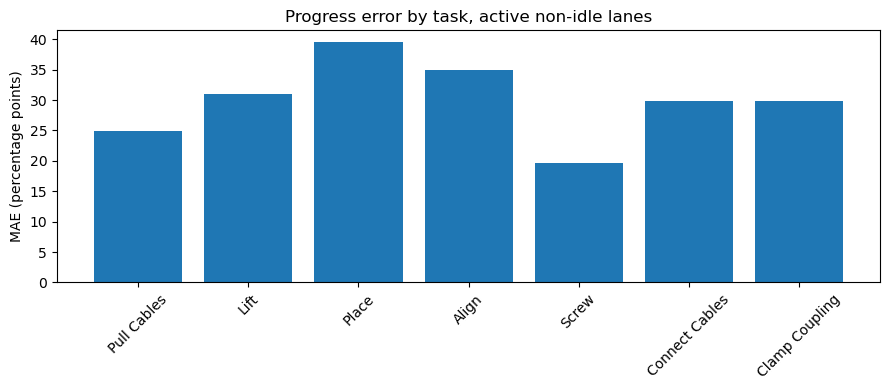

In [31]:
errors = {}
for lane, name in enumerate(TASK_NAMES):
    mask = pred_df[f"progress_active_{lane}"]
    errors[name] = 100 * (pred_df.loc[mask, f"pred_progress_{lane}"] - pred_df.loc[mask, f"true_progress_{lane}"]).abs().mean()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(errors.keys(), errors.values())
ax.tick_params(axis="x", labelrotation=45)
ax.set(ylabel="MAE (percentage points)", title="Progress error by task, active non-idle lanes")
fig.tight_layout()
fig.savefig(best_model_path_dir / "progress_prediction_abs_error_plot.png", dpi=200)
plt.show()
plt.close(fig)

### step confusion

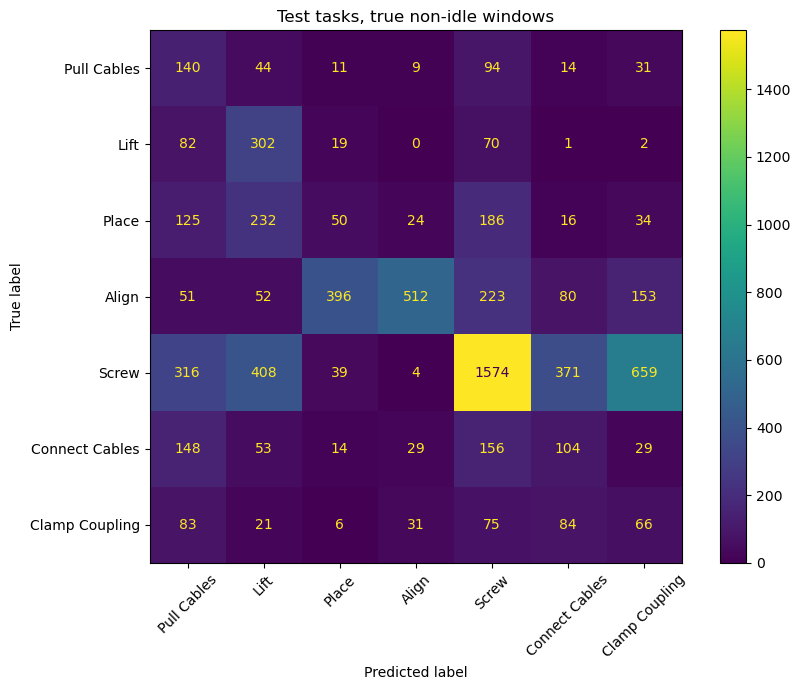

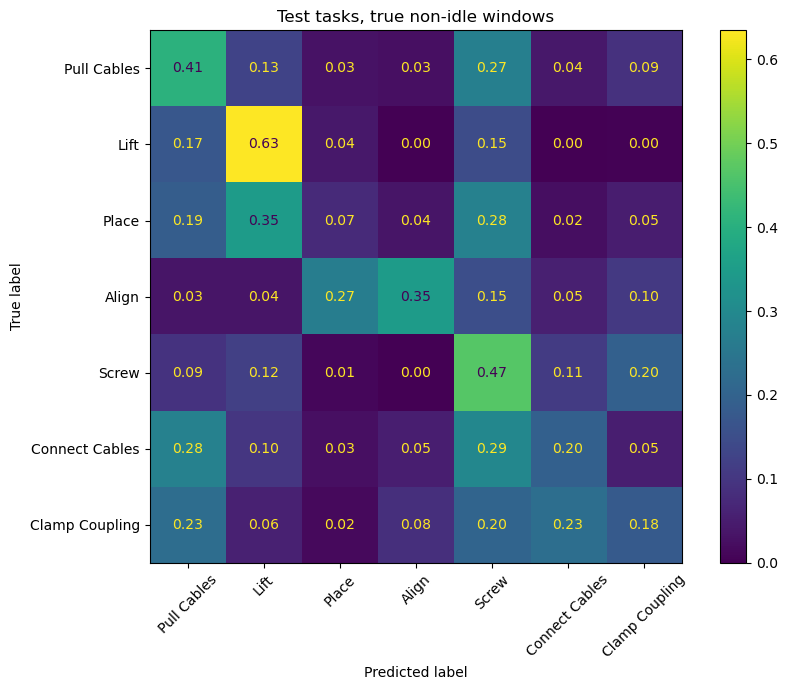

In [37]:
active_predictions = pred_df[pred_df.true_idle == 0]
for normalize, suffix, values_format in [(None, "", "d"), ("true", "_norm", ".2f")]:
    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay.from_predictions(
        active_predictions.true_step, active_predictions.pred_step, labels=range(7),
        display_labels=TASK_NAMES, normalize=normalize, values_format=values_format,
        xticks_rotation=45, ax=ax,
    )
    ax.set_title("Test tasks, true non-idle windows")
    fig.tight_layout()
    fig.savefig(best_model_path_dir / f"step_prediction_confusion_matrix{suffix}.png", dpi=200)
    plt.show()
    plt.close(fig)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(pred_df.true_idle, pred_df.pred_idle,
                                        labels=[0, 1], display_labels=["Active", "Idle"], ax=ax)
ax.set_title("Idle detection, all test windows")
fig.tight_layout()
fig.savefig(best_model_path_dir / "idle_confusion_matrix.png", dpi=200)
plt.show()
plt.close(fig)

Task lanes: 0 Pull Cables, 1 Lift, 2 Place, 3 Align, 4 Screw, 5 Connect Cables, 6 Clamp Coupling.
Idle has a separate binary head. CSV `true_step=-1` means the task metric is excluded for that window;
it is not a model output class. Each progress lane is exported independently.

### classification report

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(active_predictions.true_step, active_predictions.pred_step,
                            labels=range(7), target_names=TASK_NAMES, digits=4, zero_division=0))
print("Idle F1 (all windows):", results["idle_f1"])
print("Mistake F1 (all windows):", results["mistake_f1"])
print("Progress MAE, active non-idle lanes (0..100):", results["progress_mae_percent"])

## Idle loss curve

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(metrics_df["train_idle_loss"], label="Train")
ax.plot(metrics_df["val_idle_loss"], label="Validation")
ax.set(xlabel="Epoch", ylabel="Idle BCE", title="Idle head loss")
ax.legend()
fig.tight_layout()
fig.savefig(best_model_path_dir / "Idle_training_loss_plot.png", dpi=200)
plt.show()
plt.close(fig)

## Full 15-fold LOSO
Run `python -B -m model_lstm.LSTM_loso_tune` from the repository root.
Edit its data_root if needed. Each fold is preprocessed separately and tested using its best validation task-F1 checkpoint.
The runner reports mean/std (ddof=0) across subjects. A single notebook fold is not the reported 15-fold mean.
Extra `end_to_end_macro_f1` uses the predicted idle head to produce 0..7 labels on all windows; it does not affect Claude-compatible checkpoint selection.
